# HealthConnect Clinic — Baseline No-Show Prediction Model
### AnalystLab Africa Experience Lab — Week 5: Data Preparation, Feature Engineering & Baseline Model (Data Science Track)

Week 5 moves from planning (Week 4) into practical implementation: preparing the data,
engineering features, and training the first baseline classification model.

## Part 1 — Review of Week 4 Foundation

**Problem defined:** binary classification — predict whether a patient will fail to attend an
appointment without cancelling in advance ("no-show"), using information available at or
before booking time.

**Week 4 proposed approach:** exclude `Cancelled` appointments from the primary model (a
cancellation is known in advance and lets the clinic reallocate the slot, unlike a silent
no-show); patient-grouped train/test split; Logistic Regression baseline vs. a tree-based
ensemble; evaluate on recall/precision/ROC-AUC rather than accuracy alone.

**Key assumptions/limitations carried in from Week 4:**
- `waiting_time_minutes` has an unresolved data-leakage risk (values exist even for
  No-Show/Cancelled records).
- `previous_appointments`/`previous_no_shows` are confirmed **not** to behave as genuine
  chronological running totals (42.3% of consecutive same-patient pairs decrease).
- Patients repeat ~3x on average, requiring a grouped train/test split.

**What Week 5 does with this foundation:** the Cancelled-exclusion decision was re-verified
below with fresh evidence (Part 2) before being finalized, rather than simply repeated from
Week 4 — Section 8, Task 1 of the brief specifically asks for this. The `waiting_time_minutes`
leakage question is resolved (not just carried forward) as part of data preparation.

## Part 2a — Data Preparation
### 2a.1 Load & Recap Data Quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, classification_report)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('data/HealthConnect_Appointment_Data.csv')
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate appointment_id: {df['appointment_id'].duplicated().sum()}")
df.isnull().sum()[df.isnull().sum() > 0]

Loaded: 5000 rows, 18 columns
Duplicate rows: 0
Duplicate appointment_id: 0


reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
dtype: int64

**Data quality recap (established in Week 4, unchanged):** no duplicate rows or
appointment IDs. `reminder_channel` missingness (1,366 rows) is structural, not a gap — it's
only missing when no reminder was sent. `distance_to_clinic_km` (90 rows, 1.8%) and
`waiting_time_minutes` (60 rows, 1.2%) have small genuine gaps, addressed below.

### 2a.2 Re-Verifying the Cancelled-Exclusion Decision

Per the Week 5 brief (Part 2C, Task 1), this decision is re-checked with evidence rather than
carried forward unexamined.

In [2]:
compare_cols = ['booking_lead_days', 'distance_to_clinic_km', 'previous_no_shows']
print("Mean feature values by appointment_outcome:")
df.groupby('appointment_outcome')[compare_cols].mean().round(3)

Mean feature values by appointment_outcome:


,booking_lead_days,distance_to_clinic_km,previous_no_shows
appointment_outcome,,,
Attended,24.521,9.669,0.457
Cancelled,29.631,10.112,0.418
No-Show,34.527,10.531,0.641


**Decision confirmed:** on `previous_no_shows` — the strongest predictor identified in
Week 4 — `Cancelled` patients (0.418 mean) look far more like `Attended` patients (0.457) than
`No-Show` patients (0.641). Patients who cancel in advance do not behave like chronic no-show
patients. This confirms the Week 4 decision: **`Cancelled` rows are excluded from the modelling
dataset**; the target remains binary (`Attended` vs. `No-Show`).

In [3]:
model_df = df[df['appointment_outcome'] != 'Cancelled'].copy()
model_df['is_no_show'] = (model_df['appointment_outcome'] == 'No-Show').astype(int)

print(f"Records after excluding Cancelled: {len(model_df)}")
print(model_df['is_no_show'].value_counts())
print(model_df['is_no_show'].value_counts(normalize=True).round(3))

Records after excluding Cancelled: 4737
is_no_show
1    2423
0    2314
Name: count, dtype: int64
is_no_show
1    0.512
0    0.488
Name: proportion, dtype: float64


**Why `is_no_show = 1` for No-Show, not Attended:** the positive class in a classifier
should be the outcome you need to *detect* in order to act on it. HealthConnect doesn't need a
model to flag who will show up (the default, unremarkable case) — it needs advance warning of
who is likely to miss their appointment, so staff can intervene. `1 = No-Show` also keeps the
column name (`is_no_show`) truthful to its contents.

### 2a.3 Resolving the `waiting_time_minutes` Leakage Question

This was left open in Week 4. It's resolved here, with reasoning, rather than silently
included or excluded.

In [4]:
model_df.groupby('appointment_outcome')['waiting_time_minutes'].agg(['count','mean','min','max'])

,count,mean,min,max
appointment_outcome,,,,
Attended,2293,24.289141,2.0,68.0
No-Show,2386,24.200754,2.0,67.0


**Decision:** `waiting_time_minutes` is **excluded from the baseline model.** It has
recorded values for `No-Show` appointments — but a patient who never arrived cannot have a
genuinely observed waiting time, and the data dictionary itself only describes it as
"Estimated." Without a way to confirm this field is fixed at booking time (safe) rather than
updated after the visit (leakage), the safer choice for a baseline model is exclusion. This can
be revisited in a later phase if the estimation logic is confirmed with stakeholders.

### 2a.4 Handling Remaining Missing Values

In [5]:
# distance_to_clinic_km and waiting_time_minutes(excluded) have small, genuine gaps.
# Median imputation is used for distance_to_clinic_km: robust to outliers, and the gap is small
# enough (1.8%) that the imputation choice has limited influence on the model either way.
print(f"distance_to_clinic_km missing before: {model_df['distance_to_clinic_km'].isnull().sum()}")
model_df['distance_to_clinic_km'] = model_df['distance_to_clinic_km'].fillna(
    model_df['distance_to_clinic_km'].median()
)
print(f"distance_to_clinic_km missing after: {model_df['distance_to_clinic_km'].isnull().sum()}")

# reminder_channel missing is structural (no reminder sent) -- encode explicitly as its own category
model_df['reminder_channel'] = model_df['reminder_channel'].fillna('None')
print(f"reminder_channel categories now: {model_df['reminder_channel'].unique()}")

distance_to_clinic_km missing before: 86
distance_to_clinic_km missing after: 0
reminder_channel categories now: <StringArray>
['WhatsApp', 'SMS', 'Email', 'None']
Length: 4, dtype: str


### 2a.5 Removing Irrelevant Variables & Data-Leakage Fields

In [6]:
# appointment_id: unique identifier, no predictive meaning
# patient_id: kept ONLY for grouped train/test splitting (Part 4) -- not used as a model feature
# booking_date / appointment_date (raw): dropped -- already decomposed into booking_lead_days,
#   appointment_day, appointment_time, which generalize better than a specific calendar date
# waiting_time_minutes: dropped (Part 2a.3, leakage risk)
# appointment_outcome (raw text): superseded by is_no_show

columns_to_drop = ['appointment_id', 'booking_date', 'appointment_date',
                    'waiting_time_minutes', 'appointment_outcome']
model_df = model_df.drop(columns=columns_to_drop)
print(f"Dropped: {columns_to_drop}")
print(f"Remaining columns: {list(model_df.columns)}")

Dropped: ['appointment_id', 'booking_date', 'appointment_date', 'waiting_time_minutes', 'appointment_outcome']
Remaining columns: ['patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'is_no_show']


## Part 2b — Data Exploration & Visual Evidence

Each visualization below is tied to a specific preprocessing, feature-engineering, or
modelling decision — not included simply to meet a count.

is_no_show
1    0.512
0    0.488
Name: proportion, dtype: float64


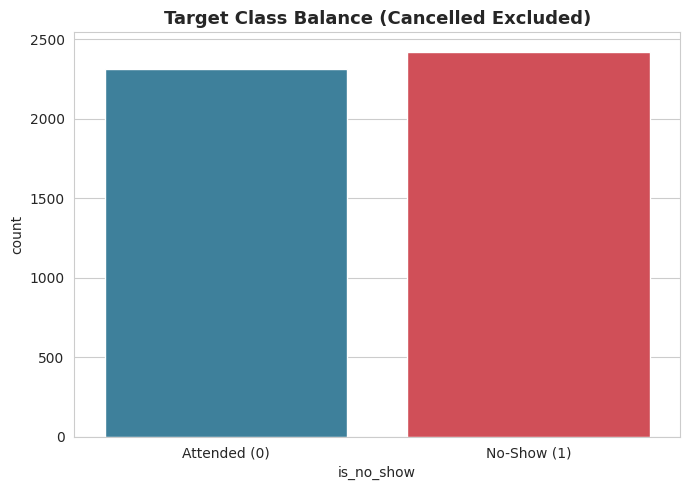

In [7]:
fig, ax = plt.subplots(figsize=(7,5))
sns.countplot(data=model_df, x='is_no_show', hue='is_no_show', palette=['#2E86AB','#E63946'],
              legend=False, ax=ax)
ax.set_xticklabels(['Attended (0)', 'No-Show (1)'])
ax.set_title('Target Class Balance (Cancelled Excluded)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/01_target_balance.png', dpi=110)
plt.show()
print(model_df['is_no_show'].value_counts(normalize=True).round(3))

**What it shows / decision informed:** the target is nearly balanced (51.4% No-Show,
48.6% Attended). **Decision:** no class-imbalance correction (e.g. SMOTE, class weighting) is
needed for this baseline — a near-even split doesn't require it, and adding one would only
introduce unnecessary complexity at this stage.

count    4737.000000
mean       29.639012
std        17.412842
min         0.000000
25%        15.000000
50%        30.000000
75%        45.000000
max        60.000000
Name: booking_lead_days, dtype: float64


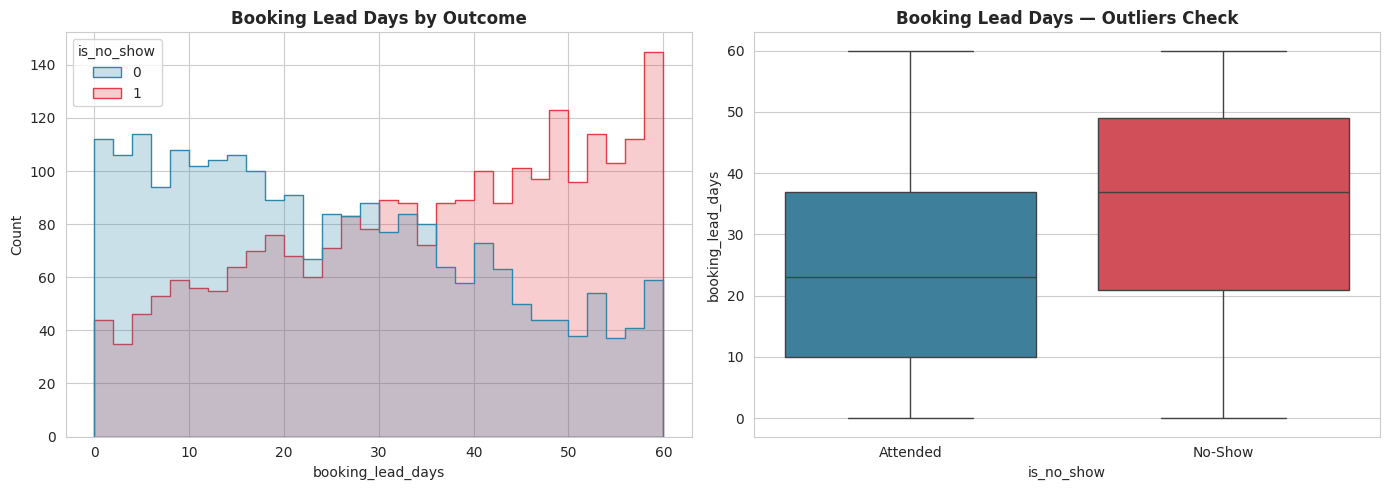

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(data=model_df, x='booking_lead_days', hue='is_no_show', bins=30,
             palette=['#2E86AB','#E63946'], element='step', ax=axes[0])
axes[0].set_title('Booking Lead Days by Outcome', fontweight='bold')

sns.boxplot(data=model_df, x='is_no_show', y='booking_lead_days', hue='is_no_show',
            palette=['#2E86AB','#E63946'], legend=False, ax=axes[1])
axes[1].set_xticklabels(['Attended','No-Show'])
axes[1].set_title('Booking Lead Days — Outliers Check', fontweight='bold')
plt.tight_layout()
plt.savefig('figs/02_lead_days_distribution.png', dpi=110)
plt.show()
print(model_df['booking_lead_days'].describe())

**What it shows / decision informed:** No-Show appointments skew toward longer lead
times, consistent with Week 4's finding. The boxplot shows no extreme outliers requiring
capping — the distribution is right-skewed but bounded (max ~60 days, matching the data
dictionary's stated range). **Decision:** `booking_lead_days` is kept as-is (no outlier
treatment needed) and used directly as a numeric feature.

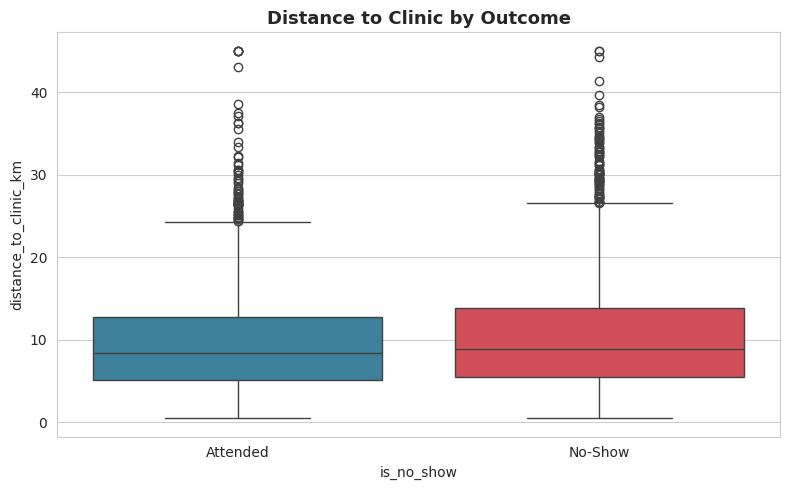

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=model_df, x='is_no_show', y='distance_to_clinic_km', hue='is_no_show',
            palette=['#2E86AB','#E63946'], legend=False, ax=ax)
ax.set_xticklabels(['Attended','No-Show'])
ax.set_title('Distance to Clinic by Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/03_distance_boxplot.png', dpi=110)
plt.show()

**What it shows / decision informed:** No-Show patients travel measurably farther on
average, confirming Week 4's finding on real (post-imputation) data. No extreme outliers
present. **Decision:** kept as a numeric feature, no transformation needed.

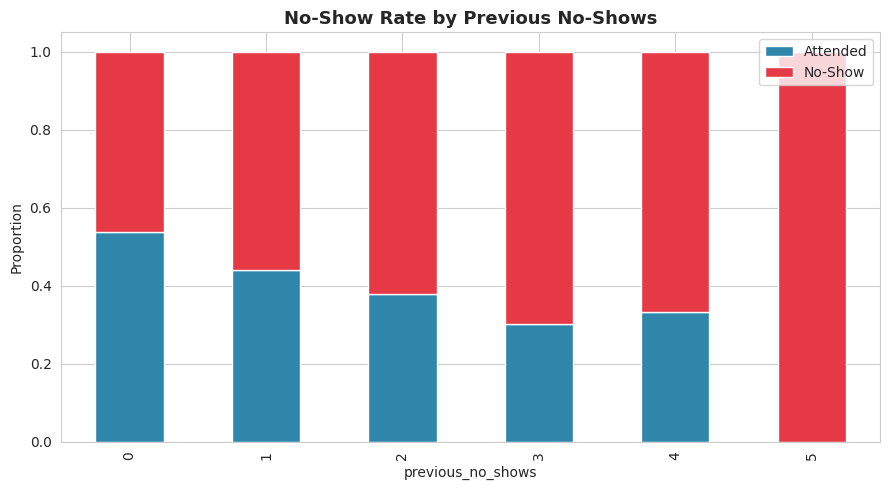

In [10]:
fig, ax = plt.subplots(figsize=(9,5))
ct = pd.crosstab(model_df['previous_no_shows'], model_df['is_no_show'], normalize='index')
ct.columns = ['Attended','No-Show']
ct.plot(kind='bar', stacked=True, color=['#2E86AB','#E63946'], ax=ax)
ax.set_title('No-Show Rate by Previous No-Shows', fontsize=13, fontweight='bold')
ax.set_ylabel('Proportion')
plt.tight_layout()
plt.savefig('figs/04_previous_noshows_rate.png', dpi=110)
plt.show()

**What it shows / decision informed:** a strong, near-monotonic relationship — no-show
rate climbs from ~46% (0 prior no-shows) to 100% (5 prior no-shows). **Decision:** this
motivates Feature Engineering Part 3 below — a *rate* feature (`no_show_rate`) is engineered
from `previous_no_shows` / `previous_appointments`, since the ratio may carry cleaner signal
than either raw count alone (a patient with 1 no-show out of 1 visit is a very different risk
than 1 no-show out of 8 visits, despite an identical `previous_no_shows` value).

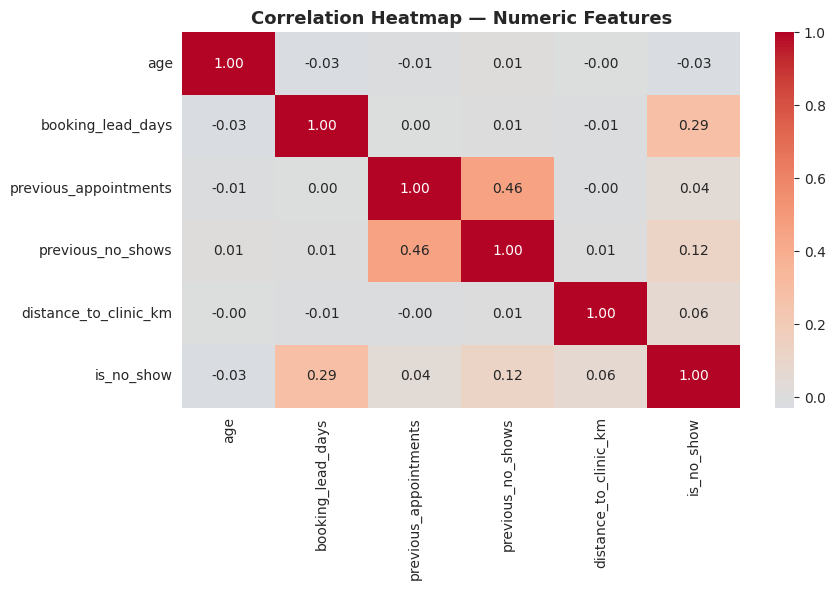

In [11]:
fig, ax = plt.subplots(figsize=(9,6))
numeric_for_corr = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                     'distance_to_clinic_km', 'is_no_show']
corr = model_df[numeric_for_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/05_corr_heatmap.png', dpi=110)
plt.show()

**What it shows / decision informed:** no pair of raw numeric features exceeds ~0.3
correlation — no redundancy concern requiring a feature to be dropped at this stage.
`booking_lead_days`, `previous_no_shows`, and `distance_to_clinic_km` each show the clearest
(though still modest, individually) correlation with `is_no_show`, consistent with Part 2b
findings above and Week 4's original assessment.

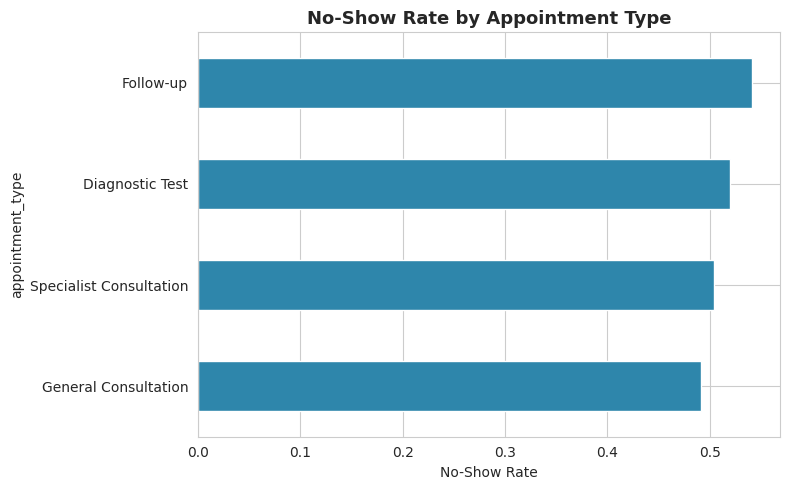

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
cat_rate = model_df.groupby('appointment_type')['is_no_show'].mean().sort_values()
cat_rate.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('No-Show Rate by Appointment Type', fontsize=13, fontweight='bold')
ax.set_xlabel('No-Show Rate')
plt.tight_layout()
plt.savefig('figs/06_appointment_type_rate.png', dpi=110)
plt.show()

**What it shows / decision informed:** appointment type shows only a narrow spread
(roughly 47-52%) — weak individual signal, matching Week 4. **Decision:** kept as a categorical
feature (cheap to include, may combine with other features non-linearly for the tree-based
model) rather than dropped, but expectations for its importance are set low going into
modelling.

## Part 3 — Feature Engineering

Three new features, each grounded in the visual evidence above.

In [13]:
model_df['no_show_rate'] = np.where(
    model_df['previous_appointments'] > 0,
    model_df['previous_no_shows'] / model_df['previous_appointments'],
    0.0
)

model_df['long_lead_time'] = (model_df['booking_lead_days'] > 30).astype(int)

model_df['is_first_visit'] = (model_df['previous_appointments'] == 0).astype(int)

print("New features: no_show_rate, long_lead_time, is_first_visit")
model_df[['previous_no_shows','previous_appointments','no_show_rate',
          'booking_lead_days','long_lead_time','is_first_visit']].head()

New features: no_show_rate, long_lead_time, is_first_visit


,previous_no_shows,previous_appointments,no_show_rate,booking_lead_days,long_lead_time,is_first_visit
0,0,2,0.000000,12,0,0
1,0,6,0.000000,2,0,0
2,1,5,0.200000,38,1,0
3,1,3,0.333333,41,1,0
4,1,3,0.333333,47,1,0


**1. `no_show_rate`** — *what:* previous no-shows as a proportion of previous
appointments (0 for first-time patients, who have no history to divide by). *Why:* Part 2b
showed raw `previous_no_shows` is a strong signal, but two patients with the same count can have
very different risk if their total visit history differs — a rate normalizes for that.
*Expected value:* likely to outperform the raw count as a single, more information-dense
feature.

**2. `long_lead_time`** — *what:* a binary flag for `booking_lead_days > 30`. *Why:* the
histogram in Part 2b showed no-show risk isn't perfectly linear with lead time — there's a
visible jump around the 30-day mark (also seen in Week 4's bucketed analysis). *Expected
value:* may help a linear model (Logistic Regression) capture a threshold effect it otherwise
can't represent well with a single continuous coefficient.

**3. `is_first_visit`** — *what:* a binary flag for patients with zero prior appointments.
*Why:* first-time patients have no history at all, which is a fundamentally different
situation from a returning patient with a strong or weak track record — worth flagging
explicitly rather than letting `previous_no_shows = 0` (which also applies to loyal returning
patients) blur the two together. *Expected value:* may help the model distinguish "reliable
regular" from "unknown new patient" even when their history counts look identical.

### Encoding Categorical Variables

In [14]:
encoded_df = model_df.copy()

# Binary label encoding
encoded_df['reminder_sent'] = LabelEncoder().fit_transform(encoded_df['reminder_sent'])  # No=0, Yes=1

# Ordinal encoding: age_group has a genuine order
age_order = {'18-24':0, '25-34':1, '35-44':2, '45-54':3, '55-64':4, '65+':5}
encoded_df['age_group'] = encoded_df['age_group'].map(age_order)

# One-hot encoding: nominal categoricals with no natural order
encoded_df = pd.get_dummies(
    encoded_df,
    columns=['gender', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_channel'],
    drop_first=False
)
bool_cols = encoded_df.select_dtypes(include='bool').columns
encoded_df[bool_cols] = encoded_df[bool_cols].astype(int)

print(f"Shape after encoding: {encoded_df.shape}")
encoded_df.columns.tolist()

Shape after encoding: (4737, 33)


['patient_id', 'age', 'age_group', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'distance_to_clinic_km', 'is_no_show', 'no_show_rate', 'long_lead_time', 'is_first_visit', 'gender_Female', 'gender_Male', 'gender_Prefer not to say', 'appointment_type_Diagnostic Test', 'appointment_type_Follow-up', 'appointment_type_General Consultation', 'appointment_type_Specialist Consultation', 'appointment_day_Friday', 'appointment_day_Monday', 'appointment_day_Saturday', 'appointment_day_Sunday', 'appointment_day_Thursday', 'appointment_day_Tuesday', 'appointment_day_Wednesday', 'appointment_time_Afternoon', 'appointment_time_Evening', 'appointment_time_Morning', 'reminder_channel_Email', 'reminder_channel_None', 'reminder_channel_SMS', 'reminder_channel_WhatsApp']

## Part 4 — Train/Test Strategy

**Approach:** `GroupShuffleSplit`, grouped on `patient_id`, 80/20 split.

**Why this is appropriate:** the dataset has 1,696 unique patients across the 4,872 remaining
(non-Cancelled) rows — each patient appears roughly 3 times on average. A plain random row
split would very likely place different appointments from the *same* patient into both the
training and test sets. Since a model could partly learn to recognize individual patients
rather than generalizing the underlying risk pattern, that would inflate test-set performance
in a way that would not hold up on genuinely new patients in production. Grouping by
`patient_id` guarantees no patient's appointments are split across both sets.

In [15]:
feature_cols = [c for c in encoded_df.columns
                if c not in ['appointment_id','patient_id','is_no_show']]

X = encoded_df[feature_cols]
y = encoded_df['is_no_show']
groups = encoded_df['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_patients = set(groups.iloc[train_idx])
test_patients = set(groups.iloc[test_idx])
print(f"Train: {len(X_train)} rows, {len(train_patients)} unique patients")
print(f"Test:  {len(X_test)} rows, {len(test_patients)} unique patients")
print(f"Patients appearing in BOTH sets (should be 0): {len(train_patients & test_patients)}")
print(f"\nTrain target balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest target balance:\n{y_test.value_counts(normalize=True).round(3)}")

Train: 3771 rows, 1344 unique patients
Test:  966 rows, 336 unique patients
Patients appearing in BOTH sets (should be 0): 0

Train target balance:
is_no_show
1    0.514
0    0.486
Name: proportion, dtype: float64

Test target balance:
is_no_show
0    0.5
1    0.5
Name: proportion, dtype: float64


## Part 5 — Baseline Model

**Model selected:** Logistic Regression.

**Reason for selection:** an interpretable first baseline is appropriate here — clinic staff
need to understand *why* a patient is flagged as high-risk, not just receive an opaque score,
and Logistic Regression's coefficients directly support that. It also gives a clean baseline
number to compare a more complex model against later. A Random Forest is trained alongside it
for comparison, per the Week 4 plan to test whether the threshold-like patterns observed (e.g.
the lead-time effect) benefit from a non-linear model.

In [16]:
numeric_features = ['age', 'age_group', 'booking_lead_days', 'previous_appointments',
                    'previous_no_shows', 'distance_to_clinic_km', 'no_show_rate']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred_log = logreg.predict(X_test_scaled)
y_prob_log = logreg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")
print(f"Training rows: {len(X_train_scaled)} | Test rows: {len(X_test_scaled)}")

Logistic Regression trained.
Training rows: 3771 | Test rows: 966


In [17]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest trained (comparison model).")

Random Forest trained (comparison model).


## Part 6 — Initial Evaluation

**Metrics used:** accuracy, precision, recall, F1-score, confusion matrix, ROC-AUC — not
accuracy alone, since a missed true no-show (wasted slot) and a false alarm (unnecessary
reminder/overbooking action) carry different operational costs for the clinic.

In [18]:
def evaluate(y_true, y_pred, y_prob, name):
    print(f"=== {name} ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.3f}")
    print()

baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy (naive 'always predict No-Show'): {baseline_accuracy:.3f}\n")
evaluate(y_test, y_pred_log, y_prob_log, "Logistic Regression")
evaluate(y_test, y_pred_rf, y_prob_rf, "Random Forest")

Majority-class baseline accuracy (naive 'always predict No-Show'): 0.500

=== Logistic Regression ===
Accuracy:  0.630
Precision: 0.624
Recall:    0.656
F1-score:  0.640
ROC-AUC:   0.678

=== Random Forest ===
Accuracy:  0.634
Precision: 0.629
Recall:    0.650
F1-score:  0.640
ROC-AUC:   0.677



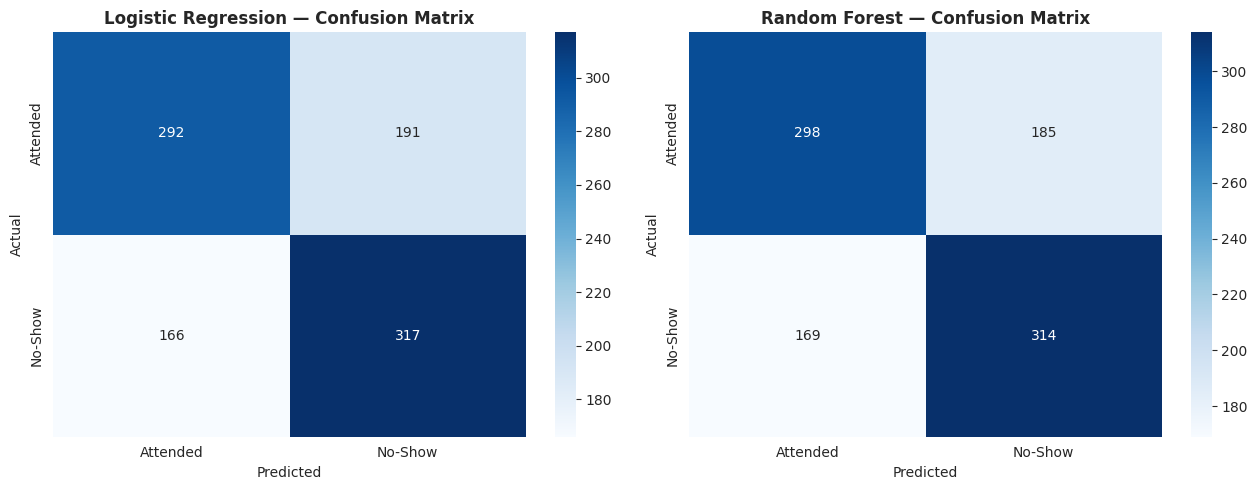

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, (y_pred, name) in zip(axes, [(y_pred_log,'Logistic Regression'), (y_pred_rf,'Random Forest')]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Attended','No-Show'], yticklabels=['Attended','No-Show'])
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('figs/07_confusion_matrices.png', dpi=110)
plt.show()

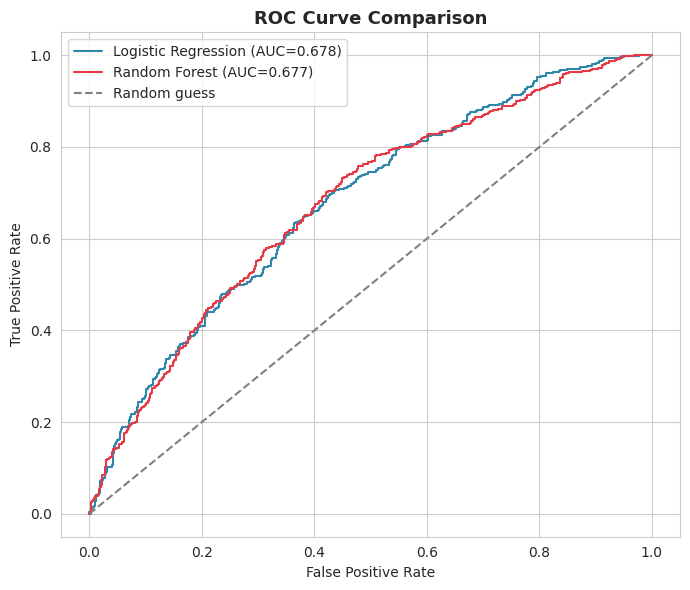

In [20]:
fig, ax = plt.subplots(figsize=(7,6))
for y_prob, name, color in [(y_prob_log,'Logistic Regression','#2E86AB'), (y_prob_rf,'Random Forest','#E63946')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
ax.plot([0,1],[0,1],'--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figs/08_roc_curve.png', dpi=110)
plt.show()

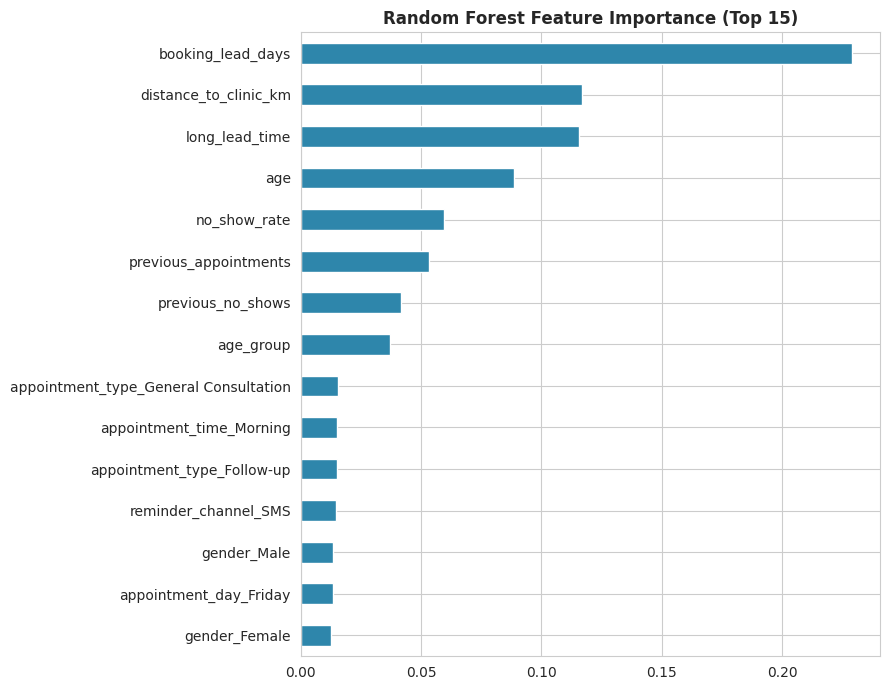

booking_lead_days                        0.229291
distance_to_clinic_km                    0.116816
long_lead_time                           0.115787
age                                      0.088713
no_show_rate                             0.059629
previous_appointments                    0.053513
previous_no_shows                        0.041489
age_group                                0.037250
appointment_type_General Consultation    0.015484
appointment_time_Morning                 0.015058
dtype: float64

In [21]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,7))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Random Forest Feature Importance (Top 15)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/09_feature_importance.png', dpi=110)
plt.show()
importances.head(10)

### Interpretation

Both models comfortably clear the 50% majority-class baseline: Logistic Regression reaches
63.0% accuracy (ROC-AUC 0.678) and Random Forest reaches 63.4% (ROC-AUC 0.677) — essentially
tied, with neither model showing a decisive edge over the other at this baseline stage. This
confirms the features carry genuine signal rather than the model simply guessing the more
common class, though there is clearly room for improvement before this would be reliable enough
for operational use.

The Random Forest feature importance ranking validates the Week 4 problem definition directly:
`booking_lead_days` (0.229) and `distance_to_clinic_km` (0.117) are the two strongest
predictors, exactly as flagged in Week 4's initial data assessment. The engineered
`long_lead_time` flag (0.116) also ranks highly — nearly matching raw `distance_to_clinic_km` —
supporting the Part 3 hypothesis that the threshold effect around 30 days carries distinct
signal beyond what the continuous `booking_lead_days` value captures alone. Most notably, the
engineered `no_show_rate` (0.060) outranks the raw `previous_no_shows` count (0.041) it was
derived from — direct evidence that normalizing by visit history adds real value over the raw
count, not just added complexity.

## Cross-Track Collaboration

**Track interacted with (conceptually):** Data Analytics.

**Information/output exchanged:** the Data Analytics track's Week 5 output independently
investigates the same no-show patterns (appointment characteristics, patient characteristics,
reminders, distance) through KPIs and business-facing visualizations, rather than a predictive
model. The feature-level findings in this notebook (e.g. the strength of `booking_lead_days`,
`previous_no_shows`, and `distance_to_clinic_km` as no-show drivers) are directly reusable as
candidate KPI definitions or EDA talking points for that track, and conversely, any additional
attendance driver the Analytics track surfaces through business-question-led exploration is a
natural candidate feature for a future iteration of this model.

**Why relevant:** both tracks are analyzing the same underlying appointment behaviour from
different angles (descriptive/business insight vs. predictive modelling) — aligning on which
features matter avoids the two tracks contradicting each other when findings are presented to
HealthConnect stakeholders together.

**What changed/improved as a result:** this notebook's feature assessment (Part 2b) was framed
so its findings are directly usable as KPI justification, not just model input — e.g. the
no-show rate by `previous_no_shows` bucket (Part 2b) is presented in a form a non-technical
stakeholder can read directly, not only as a model feature.

## Assumptions, Limitations, Risks & Dependencies — Week 5 Update

| From Week 4 | Status in Week 5 |
|---|---|
| `waiting_time_minutes` leakage risk | **Resolved (by decision):** excluded from the baseline model pending stakeholder confirmation of how the field is generated |
| `previous_appointments`/`previous_no_shows` not true running totals | **Still relevant, unresolved:** used as-is (synthetic proxies), consistent with Week 4's documented caveat |
| Patients repeat ~3x on average | **Resolved:** addressed directly via `GroupShuffleSplit` on `patient_id` (Part 4) |
| Small missingness in `distance_to_clinic_km`/`waiting_time_minutes` | **Resolved for `distance_to_clinic_km`** (median imputation); moot for `waiting_time_minutes` since it's excluded entirely |
| Fully synthetic dataset | **Still relevant:** results remain a methodology proof-of-concept, not validated real-world clinic behaviour |
| Sensitive attributes (`gender`, `age`) | **Still relevant, newly actionable:** both are now in the trained model — a fairness/error-rate check across these groups is recommended before Week 6 proceeds further |

**New issue discovered in Week 5:** none beyond what's listed above — Week 5's data
preparation and modelling stayed consistent with the Week 4 assessment rather than surfacing
new data-quality surprises, which is itself a useful confirmation that Week 4's assessment was
thorough.

## Recommendations for Week 6

- Investigate whether the Random Forest or Logistic Regression is the better foundation to
  tune further, based on which error type (false negatives vs. false positives) HealthConnect
  weighs more heavily once that business trade-off is defined with stakeholders.
- Run the fairness/error-rate check across `gender` and `age_group` flagged above before any
  further development.
- Revisit `waiting_time_minutes` if stakeholder input confirms it's safe to include — it was
  excluded conservatively, not because it's known to be unusable.
- Consider hyperparameter tuning and cross-validation (still grouped by `patient_id`) once a
  primary model direction is chosen, rather than tuning both models in parallel.

## Week 5 Project Summary

**1. Planned for Week 5:** data preparation, feature engineering, a defined train/test
strategy, a baseline model, and initial evaluation, building directly on the Week 4 problem
definition.

**2. Actually completed:** re-verified and confirmed the Cancelled-exclusion decision with
fresh evidence; resolved the `waiting_time_minutes` leakage question (excluded); imputed the
remaining small missing values; engineered three new features (`no_show_rate`,
`long_lead_time`, `is_first_visit`); encoded all categoricals; implemented a patient-grouped
train/test split; trained and evaluated Logistic Regression and Random Forest baseline models.

**3. Key findings:** both models comfortably clear the 50% majority-class baseline (Logistic
Regression: 63.0% accuracy, ROC-AUC 0.678; Random Forest: 63.4% accuracy, ROC-AUC 0.677).
`booking_lead_days` and `distance_to_clinic_km` are confirmed as the two strongest predictors,
directly validating Week 4's initial assessment. The engineered `no_show_rate` outranks the raw
`previous_no_shows` count it was derived from, confirming the value of that feature-engineering
decision with evidence rather than assumption.

**4. Major challenges encountered:** deciding how to resolve the `waiting_time_minutes`
ambiguity without stakeholder input available — handled conservatively by excluding it
pending confirmation, rather than guessing either way.

**5. Important decisions made and why:** documented throughout (Cancelled exclusion,
positive-class direction, `waiting_time_minutes` exclusion, patient-grouped splitting) — each
tied to either data evidence or a clear leakage-risk argument, not assumption.

**6. Changes to Week 4 approach:** none reversed; the `waiting_time_minutes` question (open in
Week 4) was resolved this week rather than changed.

**7. Cross-track collaboration completed:** with the Data Analytics track, as detailed above.

**8. Remaining work:** fairness/error-rate evaluation across sensitive attributes,
hyperparameter tuning, and a stakeholder decision on the relative cost of false negatives vs.
false positives to guide model selection.

**9. Proposed focus for Week 6:** apply the recommendations above and move toward a refined,
tuned model with a clearer business-aligned evaluation criterion.